# <font color='teal'> **Entrega 2**: Desarrollo de un modelo de Machine Learning Supervisado </font>

> **Curso**: Machine Learning (MLY0100)     
> **Fecha**: Octubre de 2024    
> **Profesor**: Jorge Anais     



---


Integrantes:
 - Alumno 1: Alan Ramirez
 - Alumna 2: Camilo Garrido
 - Alumno 3: Esteban Badilla



---

![Sonny and Mariel high fiving.](https://i.giphy.com/media/v1.Y2lkPTc5MGI3NjExb3F2eWhoZGc0a2k4M3BzN3B4a29lOG5jcDl0dTUycW12OWYzYTQ1NyZlcD12MV9pbnRlcm5hbF9naWZfYnlfaWQmY3Q9Zw/KPozlPlz6dOww/giphy.gif)

## <font color='teal'> 1. Parte I: Modelos de regresión </font>

### 1.1 Selección de variables

Las variables seleccionadas son las siguientes:
- Renta es una variable que indica cuanta renta pose el cliente, es de tipo Object, por lo cual sera transformada en tipo Nintz.   

- Cupo L1 es una variable que indica cuanto cupo pose el cliente para compras nacionales, es de

- Cupo L2  es una variable que indica cuanto cupo pose el cliente para avances en cuota

- Cupo_MX es una variable que indica el cupo de la tarjeta de credito para compras internacionales

- Col_T01 Colocacion del cliente en TC en el mes X

- EeccInt_01 Montos internacional exigidos en el estado de la cuenta del cliente en el mes x
- EeccNac_01 Montos internacional exigidos en el estado de la cuenta del cliente en el mes x

- Fac_T01 Montos facturado  por el cliente TC en el mes x

- FacAI_T01 Montos facturado en avances internacionales por el cliente en el mes x
- FacAN_T01 Montos facturados en avances nacionales por el cliente en el mes x

- FacCCOT_T01 Montos facturados en cuotas con tasa por el cliente en el mes x

- FacCCPC_T01 Montos facturados en cuotas precio contado por el cliente en el mes x

- FacDebAtm_T01 Montos facturados en avances por el cliente TD en el mes x

- FacDebCom_T01 Montos facturados en compras por el cliente TD en el mes x

- PagoInt_T01 Montos de pago de deuda internacional por el cliente en el mes X

- PagoNac_T01  Montos de pago de deuda nacional por el cliente en el mes X








- Explicion de eleccion de las variables: Estas variables nos ayudan a entender el comportamiento financiero del cliente: cuánto gasta, cuánto debe y cómo paga sus deudas. Esta información es esencial para predecir su Renta, ya que sus hábitos financieros suelen estar relacionados con sus ingresos.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_rows', 600)

In [2]:
# Descargar archivo
url_data_drive = "https://drive.google.com/file/d/1ulv6DSRGamOkc41ppSCiSdcDfpvJL79x/view?usp=sharing"
!gdown --fuzzy $url_data_drive

Downloading...
From: https://drive.google.com/uc?id=1ulv6DSRGamOkc41ppSCiSdcDfpvJL79x
To: /content/Base_clientes_Monopoly-0.csv
100% 87.5M/87.5M [00:00<00:00, 99.5MB/s]


In [3]:
df = pd.read_csv('Base_clientes_Monopoly-0.csv', sep=';')

/tmp/ipykernel_6514/3988445106.py:1: DtypeWarning: Columns (5,19,20,32,38,54,60,61,78,84,100,107,124,130,146,152,153,192,198,199,238,244,245,284,291,308,314,330,337,376,382,383,422,429,446,452,468,474,475,514,521,560,567) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Base_clientes_Monopoly-0.csv', sep=';')


In [4]:

# Definir las columnas que se desean mantener
columnas_a_mantener = [
    'Renta', 'CUPO_L1', 'CUPO_L2', 'CUPO_MX', 'Col_T01','Fac_T01','FacDebAtm_T01', 'FacDebCom_T01'
    , 'PagoInt_T01', 'PagoNac_T01', 'FacCN_T01', 'ColL1TE_T01',  'FacAN_T01',  'FacAI_T01'
]

# Filtrar el DataFrame
df_filtrado = df[columnas_a_mantener]


In [5]:
df_filtrado.dtypes

,0
Renta,object
CUPO_L1,int64
CUPO_L2,object
CUPO_MX,object
Col_T01,object
Fac_T01,int64
FacDebAtm_T01,int64
FacDebCom_T01,int64
PagoInt_T01,object
PagoNac_T01,int64


- Observaciones: Podemos ver que algunos de las variables a trabajar son de tipo object, por lo cual probablemente sea necesario realizar cambios de tipo en estas.

In [6]:
# Estadística descriptiva de df_filtrado
estadisticas_descriptivas = df_filtrado.describe()

# Mostrar la estadística descriptiva
print("Estadística Descriptiva del df_filtrado:")
print(estadisticas_descriptivas)

Estadística Descriptiva del df_filtrado:
            CUPO_L1       Fac_T01  FacDebAtm_T01  FacDebCom_T01   PagoNac_T01  \
count  5.112400e+04  5.112400e+04   5.112400e+04   5.112400e+04  5.112400e+04   
mean   1.133187e+06  7.097639e+04   2.306400e+05   6.967501e+04  7.637553e+04   
std    1.076922e+06  1.345565e+05   3.644859e+05   1.556583e+05  1.490256e+05   
min    0.000000e+00 -1.199000e+05   0.000000e+00   0.000000e+00  0.000000e+00   
25%    4.000000e+05  0.000000e+00   0.000000e+00   0.000000e+00  5.000000e+03   
50%    8.000000e+05  2.615000e+04   9.000000e+04   0.000000e+00  3.400150e+04   
75%    1.527000e+06  8.780000e+04   3.220000e+05   7.412900e+04  9.200000e+04   
max    2.153400e+07  4.166432e+06   8.000000e+06   4.240000e+06  8.697782e+06   

          FacCN_T01     FacAN_T01     FacAI_T01  
count  5.112400e+04  5.112400e+04  5.112400e+04  
mean   5.920637e+04  2.333281e+03  4.146368e+02  
std    1.175587e+05  2.348929e+04  1.274503e+04  
min   -1.199000e+05  0.000000

### 1.2 Correlación entre las variables

- Vamos a convertir los datos de tipo objeto a tipo numérico para poder trabajar con ellos en una matriz de correlación. Así podremos analizar mejor las relaciones entre las variables.


In [7]:
import pandas as pd

# Suponiendo que df_filtrado ya está definido
# Convertir todas las columnas a tipo numérico, forzando errores a NaN
df_filtrado = df_filtrado.apply(pd.to_numeric, errors='coerce')

# Ver los primeros registros del DataFrame convertido
print(df_filtrado.head())

# Verificar si hay valores NaN después de la conversión
print("\nValores NaN por columna:")
print(df_filtrado.isna().sum())



      Renta  CUPO_L1    CUPO_L2  CUPO_MX    Col_T01  Fac_T01  FacDebAtm_T01  \
0       NaN   798000  1012000.0   1210.0  1069735.0        0          24000   
1  143640.0   750000   150000.0   1000.0   211884.0   118247              0   
2  929106.0  1350000   200000.0   1500.0     7400.0   191336         519000   
3  172447.0  1570800   220001.0      0.0   262160.0    11890              0   
4  805250.0  2762000        2.0   6430.0   306161.0   173576              0   

   FacDebCom_T01  PagoInt_T01  PagoNac_T01  FacCN_T01  ColL1TE_T01  FacAN_T01  \
0         204133          0.0        33000          0    1040339.0          0   
1              0          0.0       300000     118247     162939.0          0   
2         162161          0.0       216676     191336          0.0          0   
3              0          0.0        60000      11890     244048.0          0   
4              0          0.0       272925     173576          0.0          0   

   FacAI_T01  
0          0  
1       


- Mostraremos una matriz de correlacion la cual nos indicara el nivel de relacion entre las variables a trabajar y mas especificamente con la columna **renta**

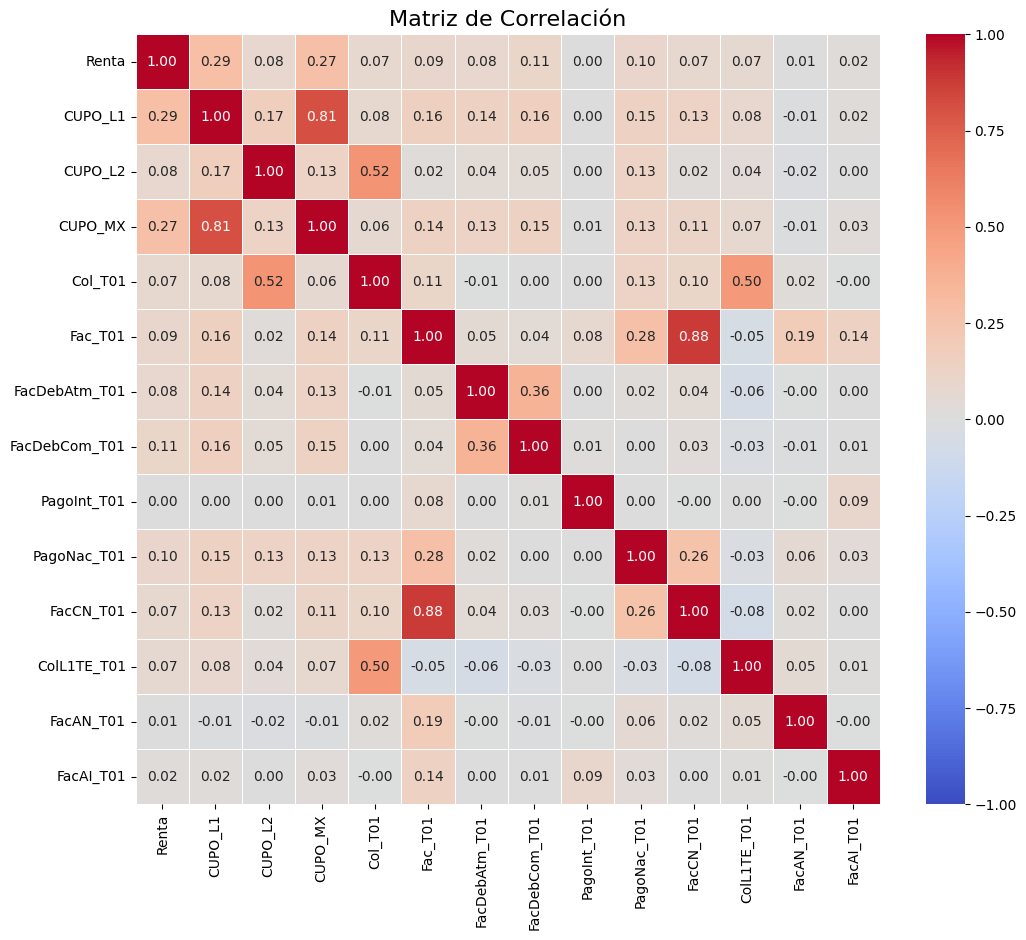

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt




# Calcular la matriz de correlación
correlation_matrix = df_filtrado.corr()


# Crear el heatmap para la matriz de correlación
plt.figure(figsize=(12, 10))  # Ajustar el tamaño de la figura según sea necesario
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1, linewidths=0.5, annot_kws={"size": 10})

# Añadir título y mostrar el heatmap
plt.title('Matriz de Correlación', fontsize=16)
plt.show()


 - Observaciones:

### 1.3 Preparación de datos


#### Aplicación de KNN variable Renta

- Aplicaremos el algoritmo KNN para imputar los valores nulos en la variable Renta, ya que es necesario completar estos datos faltantes para garantizar la integridad del conjunto de datos y permitir la construcción adecuada de los modelos de regresión.

In [9]:

import pandas as pd
from sklearn.impute import KNNImputer

# 1. Crear una copia del DataFrame original para preservar df_filtrado
df_imputado = df_filtrado.copy()

# 2. Separar la columna Renta y las variables predictoras
X = df_imputado.drop(columns=['Renta'])  # Variables predictoras
y = df_imputado[['Renta']]  # Columna objetivo (Renta) con valores nulos

# 3. Unir ambas partes para preparar el imputador
data_para_imputar = pd.concat([X, y], axis=1)

# 4. Inicializar el KNNImputer (k=5 vecinos)
imputer = KNNImputer(n_neighbors=5)

# 5. Imputar los valores nulos solo en la columna Renta
data_imputada = pd.DataFrame(imputer.fit_transform(data_para_imputar),
                             columns=data_para_imputar.columns)

# 6. Actualizar la columna Renta con los valores imputados
df_imputado['Renta'] = data_imputada['Renta']

# 7. Verificar si quedan nulos en la columna Renta
print('Numero de datos nulos en renta:')

print(df_imputado['Renta'].isnull().sum())


Numero de datos nulos en renta:
0


- Como podemos observar no hay datos nulos presentes en "renta"

#### Escalamiento de los datos

- Para lograr un mejor manejo y consistencia de los datos, aplicaremos escalado a las variables, garantizando una mayor homogeneidad y mejorando el desempeño de los modelos.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

# 1. Crear el escalador
scaler = StandardScaler()

# 2. Identificar las columnas numéricas
numerical_cols = data_imputada.select_dtypes(include=[np.number]).columns

# 3. Aplicar el escalador y asignar a un nuevo DataFrame
data_imputada_scaled = data_imputada.copy()  # Hacer una copia del DataFrame original
data_imputada_scaled[numerical_cols] = scaler.fit_transform(data_imputada[numerical_cols])

# Ver los datos escalados
print(data_imputada_scaled.head())



    CUPO_L1   CUPO_L2   CUPO_MX   Col_T01   Fac_T01  FacDebAtm_T01  \
0 -0.311248  0.901941 -0.119218  1.515922 -0.527489      -0.566941   
1 -0.355820 -0.235575 -0.250662 -0.163844  0.351310      -0.632788   
2  0.201329 -0.169594  0.062300 -0.564246  0.894500       0.791150   
3  0.406359 -0.143200 -0.876587 -0.065398 -0.439124      -0.632788   
4  1.512486 -0.433516  3.148111  0.020761  0.762510      -0.632788   

   FacDebCom_T01  PagoInt_T01  PagoNac_T01  FacCN_T01  ColL1TE_T01  FacAN_T01  \
0       0.863811    -0.016858    -0.291064  -0.503637     3.516893  -0.099335   
1      -0.447620    -0.016858     1.500592   0.502227     0.161406  -0.099335   
2       0.594166    -0.016858     0.941461   1.123957    -0.461731  -0.099335   
3      -0.447620    -0.016858    -0.109885  -0.402495     0.471595  -0.099335   
4      -0.447620    -0.016858     1.318910   0.972882    -0.461731  -0.099335   

   FacAI_T01     Renta  
0  -0.032534 -0.571018  
1  -0.032534 -1.288258  
2  -0.032534  0.7

### 1.4 Ajuste modelos de regresión

- Desarrollaremos cinco modelos distintos para predecir la variable Renta, con el objetivo de identificar cuál de ellos se ajusta mejor a los datos y proporciona la mayor precisión en las predicciones.

- Modelo 1 Regresion Lineal

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np

# 1. Preparar los datos
X = data_imputada_scaled.drop(columns=['Renta'])  # Variables predictoras
y = data_imputada_scaled['Renta']  # Variable objetivo

# 2. División de datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Entrenar el modelo de regresión lineal
modelo = LinearRegression()
modelo.fit(X_train, y_train)

# 4. Realizar predicciones
y_pred = modelo.predict(X_test)

# 5. Evaluar el modelo con varias métricas
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)  # Error cuadrático medio raíz
mae = mean_absolute_error(y_test, y_pred)  # Error absoluto medio
mape = mean_absolute_percentage_error(y_test, y_pred) * 100  # Error porcentual absoluto medio
r2 = r2_score(y_test, y_pred)  # R²

# Mostrar las métricas
print(f"Error Cuadrático Medio (MSE): {mse:.2f}")
print(f"Error Cuadrático Medio Raíz (RMSE): {rmse:.2f}")


print(f"Coeficiente de Determinación (R²): {r2:.2f}")





Error Cuadrático Medio (MSE): 0.88
Error Cuadrático Medio Raíz (RMSE): 0.94
Coeficiente de Determinación (R²): 0.14


-Observaciones: El modelo tiene un error moderado, pero solo está explicando el 22% de los datos. Básicamente, no está captando bien las relaciones importantes y necesita ajustes para ser más preciso.

- Modelo 2 Regresion Polinomial factor 2

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np

# 1. Preparar los datos
X = data_imputada.drop(columns=['Renta'])  # Variables predictoras
y = data_imputada['Renta']  # Variable objetivo

# 2. División de datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Transformación polinómica (Ajusta el grado del polinomio aquí)
grado_polinomio = 2  # Cambia el grado según sea necesario
poly = PolynomialFeatures(degree=grado_polinomio)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# 4. Entrenar el modelo de regresión polinomial
modelo_poly = LinearRegression()
modelo_poly.fit(X_train_poly, y_train)

# 5. Realizar predicciones
y_pred_poly = modelo_poly.predict(X_test_poly)

# 6. Evaluar el modelo con métricas
mse_poly = mean_squared_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
mae_poly = mean_absolute_error(y_test, y_pred_poly)
mape_poly = mean_absolute_percentage_error(y_test, y_pred_poly) * 100
r2_poly = r2_score(y_test, y_pred_poly)

# Mostrar las métricas
print(f"Error Cuadrático Medio (MSE): {mse_poly:.2f}")
print(f"Error Cuadrático Medio Raíz (RMSE): {rmse_poly:.2f}")
print(f"Coeficiente de Determinación (R²): {r2_poly:.2f}")


Error Cuadrático Medio (MSE): 126052489503.71
Error Cuadrático Medio Raíz (RMSE): 355038.72
Coeficiente de Determinación (R²): 0.13


-Observaciones:
El modelo tiene errores bastante grandes y solo está explicando el 23% de los datos, lo que significa que no está captando bien las relaciones importantes. Necesita mejoras para que sea más preciso.

- Modelo 3 Regresion Polinomial factor 3




In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np

# 1. Preparar los datos
X = data_imputada.drop(columns=['Renta'])  # Variables predictoras
y = data_imputada['Renta']  # Variable objetivo

# 2. División de datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Transformación polinómica (Ajusta el grado del polinomio aquí)
grado_polinomio = 3  # Cambia el grado según sea necesario
poly = PolynomialFeatures(degree=grado_polinomio)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# 4. Entrenar el modelo de regresión polinomial
modelo_poly = LinearRegression()
modelo_poly.fit(X_train_poly, y_train)

# 5. Realizar predicciones
y_pred_poly = modelo_poly.predict(X_test_poly)

# 6. Evaluar el modelo con métricas
mse_poly = mean_squared_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
mae_poly = mean_absolute_error(y_test, y_pred_poly)
mape_poly = mean_absolute_percentage_error(y_test, y_pred_poly) * 100
r2_poly = r2_score(y_test, y_pred_poly)

# Mostrar las métricas
print(f"Error Cuadrático Medio (MSE): {mse_poly:.2f}")
print(f"Error Cuadrático Medio Raíz (RMSE): {rmse_poly:.2f}")
print(f"Coeficiente de Determinación (R²): {r2_poly:.2f}")

Error Cuadrático Medio (MSE): 133435135503271526400.00
Error Cuadrático Medio Raíz (RMSE): 11551412705.95
Coeficiente de Determinación (R²): -916774955.94


-Observaciones: El modelo tiene un error enorme y un R² negativo (-0.50), lo que significa que, en lugar de ayudar, está haciendo predicciones peor que si simplemente se usara la media de los datos. En resumen, no está captando nada útil y necesita ajustes grandes o un enfoque diferente para mejorar.

- Modelos de regresion 4 Random forest Gump

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np

from sklearn.ensemble import RandomForestRegressor


# 1. Preparar los datos
X = data_imputada.drop(columns=['Renta'])  # Variables predictoras
y = data_imputada['Renta']  # Variable objetivo

# 2. División de datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Entrenar el modelo Random Forest con MSE (Gini)
modelo_rf_mse = RandomForestRegressor(criterion='squared_error', random_state=42)
modelo_rf_mse.fit(X_train, y_train)

# 4. Realizar predicciones
y_pred_rf_mse = modelo_rf_mse.predict(X_test)

# 5. Evaluar el modelo con métricas
mse_mse = mean_squared_error(y_test, y_pred_rf_mse)
rmse_mse = np.sqrt(mse_mse)
mae_mse = mean_absolute_error(y_test, y_pred_rf_mse)
mape_mse = mean_absolute_percentage_error(y_test, y_pred_rf_mse) * 100
r2_mse = r2_score(y_test, y_pred_rf_mse)

# 6. Mostrar métricas del modelo MSE
print("\n--- Random Forest con MSE (Gini) ---")
print(f"MSE: {mse_mse:.2f}")
print(f"RMSE: {rmse_mse:.2f}")
print(f"R²: {r2_mse:.2f}")


--- Random Forest con MSE (Gini) ---
MSE: 116689392076.06
RMSE: 341598.29
R²: 0.20


-Observaciones:
El modelo tiene un error considerable, con un RMSE de 175,301, lo que indica que las predicciones están bastante alejadas de los valores reales. El R² de 0.48 sugiere que el modelo está explicando un 48% de la variabilidad de los datos, lo que no es terrible, pero aún deja mucho margen para mejorar. En resumen, el modelo está captando algunas relaciones, pero necesita ajustes para ser más preciso.

- Modelo 5 Random forest Entropia

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np

from sklearn.ensemble import RandomForestRegressor

# 1. Preparar los datos
X = data_imputada.drop(columns=['Renta'])  # Variables predictoras
y = data_imputada['Renta']  # Variable objetivo

# 2. División de datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Entrenar el modelo Random Forest con MAE (Entropía)
modelo_rf_mae = RandomForestRegressor(criterion='poisson', random_state=42)
modelo_rf_mae.fit(X_train, y_train)

# 4. Realizar predicciones
y_pred_rf_mae = modelo_rf_mae.predict(X_test)

# 5. Evaluar el modelo con métricas
mse_mae = mean_squared_error(y_test, y_pred_rf_mae)
rmse_mae = np.sqrt(mse_mae)
mae_mae = mean_absolute_error(y_test, y_pred_rf_mae)
mape_mae = mean_absolute_percentage_error(y_test, y_pred_rf_mae) * 100
r2_mae = r2_score(y_test, y_pred_rf_mae)

# 6. Mostrar métricas del modelo MAE
print("\n--- Random Forest con MAE (Entropía) ---")
print(f"MSE: {mse_mae:.2f}")
print(f"RMSE: {rmse_mae:.2f}")
print(f"R²: {r2_mae:.2f}")


--- Random Forest con MAE (Entropía) ---
MSE: 116417369842.28
RMSE: 341199.90
R²: 0.20


-Observaciones: El modelo presenta un error significativo, con un RMSE de 174,852, y explica solo el 48% de la variabilidad de los datos. Aunque está captando algunas relaciones, necesita ajustes para mejorar su precisión.

### 1.5 Evaluación de los modelos)

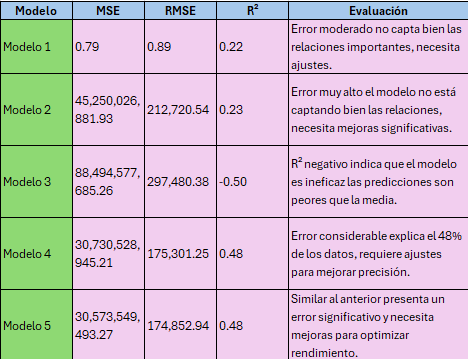

#Conclusiones generales de la evaluacion de los modelos:
Los Modelos 1 y 2 tienen un rendimiento bajo, con errores altos y un R² bajo, lo que indica que no captan bien las relaciones en los datos. El Modelo 3 es el menos efectivo, con un R² negativo, lo que significa que sus predicciones son peores que simplemente usar la media. Los Modelos 4 y 5 muestran un mejor ajuste con un R² más alto, pero aún necesitan mejoras para aumentar su precisión.

#Eleccion del modelo
Aunque todos los modelos pueden mejorar, el Modelo 4 es el que mejor se desempeña, ya que tiene una buena combinación entre precisión en las predicciones y capacidad para explicar lo que sucede en los datos.

## <font color='teal'>2. Parte II: Modelos de clasificación</font>

### 2.1 Selección de variables

- Target:Indica si el cliente paga un monto mayor (1) o inferior (0) al
pago mínimo de la tarjeta de crédito.


- Cupo L1 es una variable que indica cuanto cupo pose el cliente para compras nacionales, es de

- Cupo L2  es una variable que indica cuanto cupo pose el cliente para avances en cuota

- Cupo_MX es una variable que indica el cupo de la tarjeta de credito para compras internacionales

- Col_T01 Colocacion del cliente en TC en el mes X

- EeccInt_T01 Montos internacional exigindos en el estado de la cuenta del cliente en el mes x
- EeccNac_T01 Montos internacional exigindos en el estado de la cuenta del cliente en el mes x

- Fac_T01 Montos facturado  por el cliente TC en el mes x

- FacAI_T01 Montos facturado en avances internacionales por el cliente en el mes x
- FacAN_T01 Montos facturados en avances nacionales por el cliente en el mes x

- FacCCOT_T01 Montos facturados en cuotas con tasa por el cliente en el mes x

- FacCCPC_T01 Montos facturados en cuotas precio contado por el cliente en el mes x

- FacDebAtm_T01 Montos facturados en avances por el cliente TD en el mes x

- FacDebCom_T01 Montos facturados en compras por el cliente TD en el mes x

- PagoInt_T01 Montos de pago de deuda internacional por el cliente en el mes X

- PagoNac_T01  Montos de pago de deuda nacional por el cliente en el mes X





- Explicion de eleccion de las variables: Estas variables nos ayudan a entender el comportamiento financiero del cliente: cuánto gasta, cuánto debe y cómo paga sus deudas. Esta información es esencial para predecir su Renta, ya que sus hábitos financieros suelen estar relacionados con sus ingresos.

In [ ]:
columnas_a_mantener2 = [
   'CUPO_L1', 'CUPO_L2', 'CUPO_MX', 'Col_T01','Fac_T01','FacDebAtm_T01', 'FacDebCom_T01',
   'PagoInt_T01', 'PagoNac_T01', 'FacAN_T01', 'EeccInt_T01',  'EeccNac_T01',  'FacAI_T01', 'target','FacCCPC_T01','FacCCOT_T01'
]

# Filtrar el DataFrame
df_filtrado2 = df[columnas_a_mantener2]

### 2.2 Correlación entre las variables seleccionadas

- Convertimos las columnas a numeric para poder ver su relacion

In [ ]:
import pandas as pd

# Suponiendo que df_filtrado2 ya está definido
# Convertir todas las columnas a tipo numérico, forzando errores a NaN
df_filtrado2 = df_filtrado2.apply(pd.to_numeric, errors='coerce')

# Ver los primeros registros del DataFrame convertido
print(df_filtrado2.head())

# Verificar si hay valores NaN después de la conversión
print("\nValores NaN por columna:")
print(df_filtrado2.isna().sum())

   CUPO_L1    CUPO_L2  CUPO_MX    Col_T01  Fac_T01  FacDebAtm_T01  \
0   798000  1012000.0   1210.0  1069735.0        0          24000   
1   750000   150000.0   1000.0   211884.0   118247              0   
2  1350000   200000.0   1500.0     7400.0   191336         519000   
3  1570800   220001.0      0.0   262160.0    11890              0   
4  2762000        2.0   6430.0   306161.0   173576              0   

   FacDebCom_T01  PagoInt_T01  PagoNac_T01  FacAN_T01  EeccInt_T01  \
0         204133          0.0        33000          0          0.0   
1              0          0.0       300000          0          0.0   
2         162161          0.0       216676          0          0.0   
3              0          0.0        60000          0          0.0   
4              0          0.0       272925          0          0.0   

   EeccNac_T01  FacAI_T01  target  FacCCPC_T01  FacCCOT_T01  
0    1099866.0          0       0            0            0  
1     214592.0          0       0       

In [ ]:
df_filtrado2.dtypes

,0
CUPO_L1,int64
CUPO_L2,float64
CUPO_MX,float64
Col_T01,float64
Fac_T01,int64
FacDebAtm_T01,int64
FacDebCom_T01,int64
PagoInt_T01,float64
PagoNac_T01,int64
FacAN_T01,int64


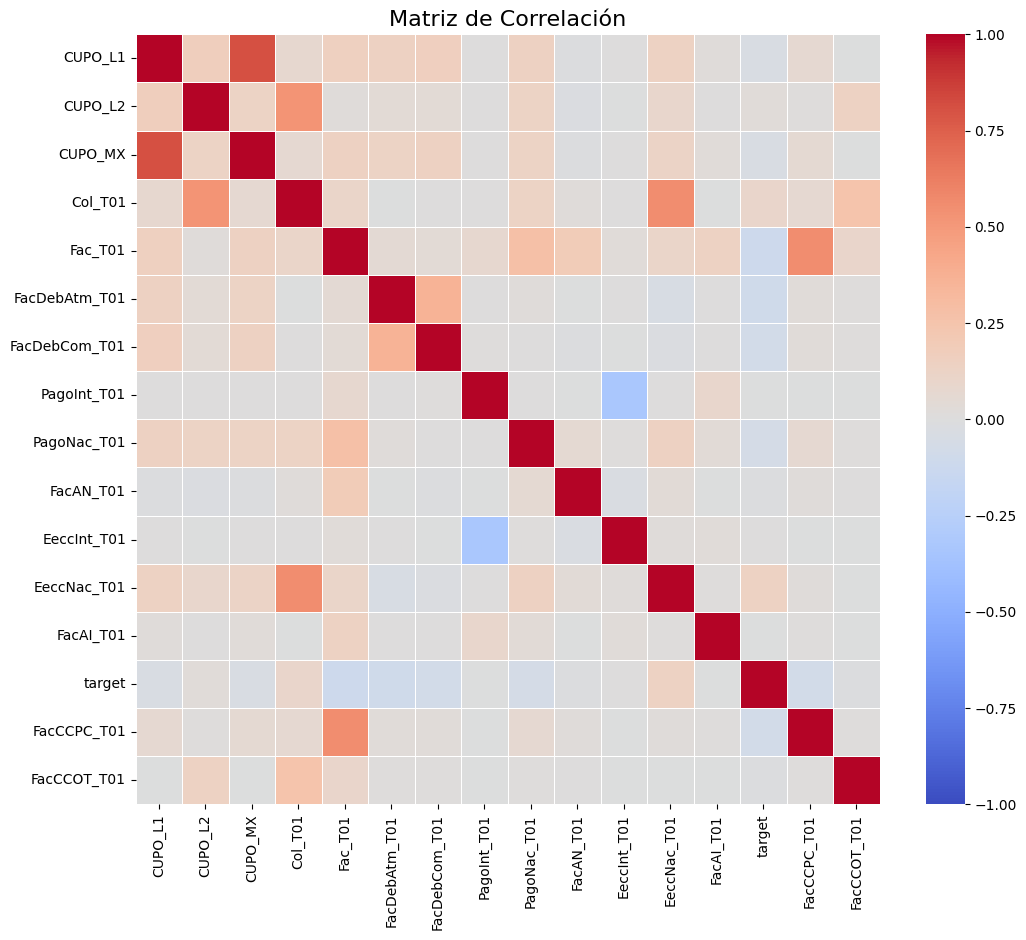

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


# Calcular la matriz de correlación
correlation_matrix = df_filtrado2.corr()

# Crear el heatmap para la matriz de correlación
plt.figure(figsize=(12, 10))  # Ajustar el tamaño de la figura según sea necesario
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1, linewidths=0.5, annot_kws={"size": 10})

# Añadir título y mostrar el heatmap
plt.title('Matriz de Correlación', fontsize=16)
plt.show()

### 2.3 Preparación de datos

Aplicación de KNN a la columna Col_T01 la cual posee 2244 nulos

In [ ]:
# Crear una copia del DataFrame original para preservar df_filtrado
df_imputado = df_filtrado2.copy()

# Separar la columna que quieres imputar y las variables predictoras
X = df_imputado.drop(columns=['Col_T01'])  # Variables predictoras sin incluir 'Col_T01'
col_to_impute = df_imputado[['Col_T01']]  # Columna que necesita imputación (Col_T01)

# Concatenar solo las variables predictoras con la columna a imputar
data_para_imputar = pd.concat([X, col_to_impute], axis=1)

# Inicializar el KNNImputer (k=5 vecinos)
imputer = KNNImputer(n_neighbors=5)

# Imputar los valores nulos solo en la columna Col_T01
data_imputada = pd.DataFrame(imputer.fit_transform(data_para_imputar),
                             columns=data_para_imputar.columns)

# Actualizar la columna Col_T01 con los valores imputados
df_imputado['Col_T01'] = data_imputada['Col_T01']


In [ ]:
print(df_imputado.isnull().sum())

CUPO_L1             0
CUPO_L2            21
CUPO_MX             1
Col_T01             0
Fac_T01             0
FacDebAtm_T01       0
FacDebCom_T01       0
PagoInt_T01       300
PagoNac_T01         0
FacAN_T01           0
EeccInt_T01      3266
EeccNac_T01         3
FacAI_T01           0
target              0
FacCCPC_T01         0
FacCCOT_T01         0
dtype: int64


- Aplicar smolder  
- Aplicar escalamiento

#### Escalamiento

- Para lograr un mejor manejo y consistencia de los datos, aplicaremos escalado a las variables, garantizando una mayor homogeneidad y mejorando el desempeño de los modelos.

In [ ]:
# 1. Crear el escalador
scaler = StandardScaler()

# 2. Identificar las columnas numéricas
numerical_cols = data_imputada.select_dtypes(include=[np.number]).columns

# 3. Aplicar el escalador y asignar a un nuevo DataFrame
data_imputada_scaled = data_imputada.copy()  # Hacer una copia del DataFrame original
data_imputada_scaled[numerical_cols] = scaler.fit_transform(data_imputada[numerical_cols])

# Ver los datos escalados
print(data_imputada_scaled.head())

    CUPO_L1   CUPO_L2   CUPO_MX   Fac_T01  FacDebAtm_T01  FacDebCom_T01  \
0 -0.311248  0.901980 -0.119204 -0.527489      -0.566941       0.863811   
1 -0.355820 -0.235528 -0.250661  0.351310      -0.632788      -0.447620   
2  0.201329 -0.169548  0.062332  0.894500       0.791150       0.594166   
3  0.406359 -0.143154 -0.876646 -0.439124      -0.632788      -0.447620   
4  1.512486 -0.433468  3.148438  0.762510      -0.632788      -0.447620   

   PagoInt_T01  PagoNac_T01  FacAN_T01  EeccInt_T01  EeccNac_T01  FacAI_T01  \
0    -0.016883    -0.291064  -0.099335    -0.005558     3.140316  -0.032534   
1    -0.016883     1.500592  -0.099335    -0.005558     0.071595  -0.032534   
2    -0.016883     0.941461  -0.099335    -0.005558    -0.672269  -0.032534   
3    -0.016883    -0.109885  -0.099335    -0.005558     0.273236  -0.032534   
4    -0.016883     1.318910  -0.099335    -0.005558     0.192815  -0.032534   

     target  FacCCPC_T01  FacCCOT_T01   Col_T01  
0 -0.314442    -0.298310

In [ ]:
X = df_imputado.drop(columns=['target'])
y = df_imputado['target']

In [ ]:
df_escalado = pd.DataFrame(df_imputado)

In [ ]:
print(df_escalado.isnull().sum())

CUPO_L1             0
CUPO_L2            21
CUPO_MX             1
Col_T01             0
Fac_T01             0
FacDebAtm_T01       0
FacDebCom_T01       0
PagoInt_T01       300
PagoNac_T01         0
FacAN_T01           0
EeccInt_T01      3266
EeccNac_T01         3
FacAI_T01           0
target              0
FacCCPC_T01         0
FacCCOT_T01         0
dtype: int64


In [ ]:
df_escalado.dropna(inplace=True)

#### Smote


- Vamos a aplicar la tecnica SMOTE para balancear la clase que necesitamos predecir en nuestros modelos de clasificación. Esta técnica nos ayudará a generar muestras sintéticas de la clase minoritaria, mejorando así la precisión y la efectividad del modelo.

In [ ]:
from imblearn.over_sampling import SMOTE

In [ ]:
X = df_escalado.drop(columns=['target'])
y = df_escalado['target']

In [ ]:
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X, y)

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(X_smote, y_smote, test_size=0.2, random_state=42)

In [ ]:
print("Distribución de clases SMOTE:", y_train.value_counts())

Distribución de clases SMOTE: target
0    34707
1    34659
Name: count, dtype: int64


### 2.4 Ajuste modelos de clasificacion

- Desarrollaremos cinco modelos de clasificacion distintos para predecir la variable Target, con el objetivo de identificar cuál de ellos se ajusta mejor a los datos y proporciona la mayor precisión en las predicciones.

# Modelo clasificacion 1 Arboles de decision

              precision    recall  f1-score   support

           0       0.86      0.83      0.84      8647
           1       0.84      0.86      0.85      8695

    accuracy                           0.85     17342
   macro avg       0.85      0.85      0.85     17342
weighted avg       0.85      0.85      0.85     17342

Precisión: 84.62%


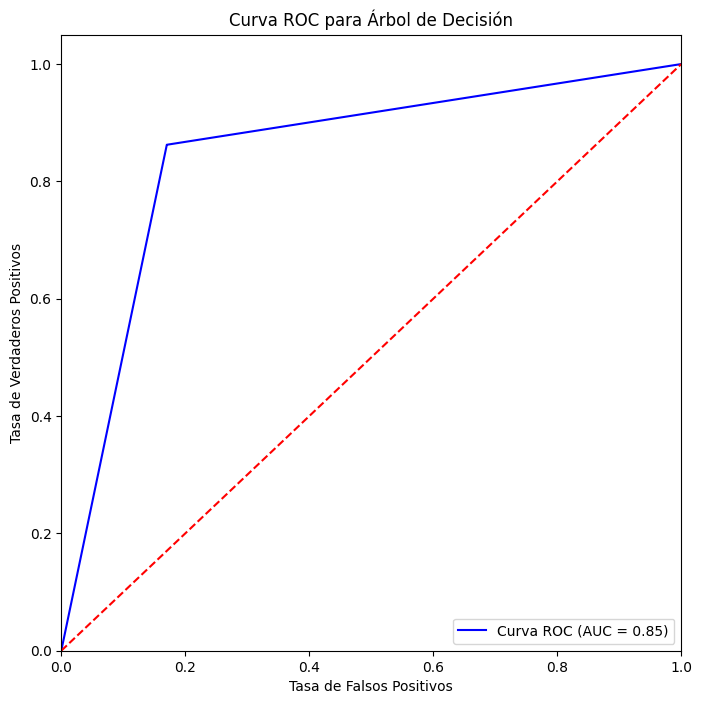

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_curve, auc
import matplotlib.pyplot as plt

# 1. Preparar los datos
# Separar características y variable objetivo
X = df_escalado.drop(columns=['target'])  # Variables predictoras
y = df_escalado['target']  # Variable objetivo

# 2. Entrenar el modelo de Árbol de Decisión
modelo_arbol = DecisionTreeClassifier(random_state=42)
modelo_arbol.fit(x_train, y_train)

# 3. Realizar predicciones
y_pred = modelo_arbol.predict(x_test)

# 4. Evaluar el modelo
# 5.1. Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# 5.2. Reporte de clasificación
report = classification_report(y_test, y_pred)
print(report)

# 5.3. Precisión
accuracy = round(accuracy_score(y_test, y_pred) * 100, 2)
print(f'Precisión: {accuracy}%')

# 5.4. Curva ROC y AUC
# Calcular las probabilidades de la clase positiva
y_scores = modelo_arbol.predict_proba(x_test)[:, 1]

# Calcular la curva ROC y AUC
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)


# Graficar la curva ROC
plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, color='blue', label='Curva ROC (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Línea diagonal
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC para Árbol de Decisión')
plt.legend(loc='lower right')
plt.show()



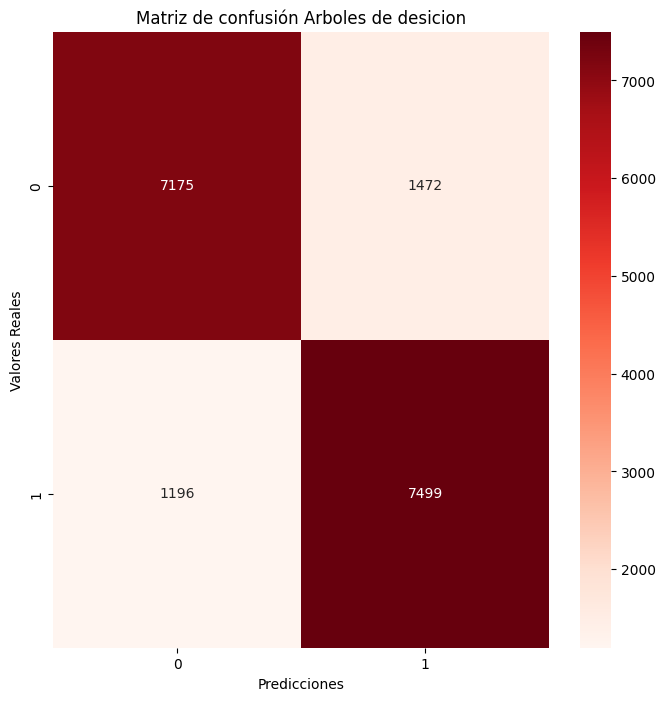

              precision    recall  f1-score   support

           0       0.86      0.83      0.84      8647
           1       0.84      0.86      0.85      8695

    accuracy                           0.85     17342
   macro avg       0.85      0.85      0.85     17342
weighted avg       0.85      0.85      0.85     17342



In [ ]:
plt.figure(figsize=(8, 8))
sns.heatmap(cm, xticklabels=["0","1"], yticklabels=["0","1"], annot=True, fmt="d",cmap="Reds");
plt.title("Matriz de confusión Arboles de desicion")
plt.ylabel('Valores Reales')
plt.xlabel('Predicciones')
plt.show()
print (classification_report(y_test, y_pred))

- Observaciones: el modelo se está comportando bastante bien. Tiene una buena precisión, con la clase 0 en 86% y la clase 1 en 84%, lo que significa que clasifica bien la mayoría de las muestras. También tiene un buen recall, identificando la mayoría de los casos positivos en ambas clases. Los F1-scores están entre 84% y 85%, lo que muestra un buen equilibrio. La exactitud general es del 85%, y los promedios también están en 0.85, así que no parece estar sesgado hacia ninguna clase. En general, está rindiendo bastante bien.

# Modelo de clasificacion 2 Arboles de decisiones (Con Hiperparametros)

              precision    recall  f1-score   support

           0       0.73      0.69      0.71      8647
           1       0.71      0.75      0.73      8695

    accuracy                           0.72     17342
   macro avg       0.72      0.72      0.72     17342
weighted avg       0.72      0.72      0.72     17342

Precisión: 71.92%


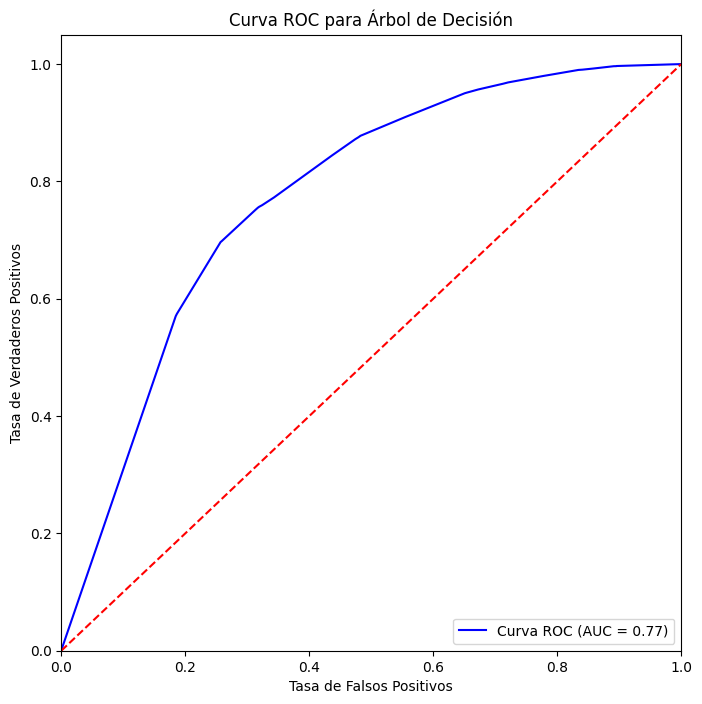

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_curve, auc
import matplotlib.pyplot as plt

# 1. Preparar los datos
# Separar características y variable objetivo
X = df_escalado.drop(columns=['target'])  # Variables predictoras
y = df_escalado['target']  # Variable objetivo

# 2. Entrenar el modelo de Árbol de Decisión
modelo_arbol = DecisionTreeClassifier(random_state=42,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    criterion='gini')
modelo_arbol.fit(x_train, y_train)

# 3. Realizar predicciones
y_pred = modelo_arbol.predict(x_test)

# 4. Evaluar el modelo
# 5.1. Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# 5.2. Reporte de clasificación
report = classification_report(y_test, y_pred)
print(report)

# 5.3. Precisión
accuracy = round(accuracy_score(y_test, y_pred) * 100, 2)
print(f'Precisión: {accuracy}%')

# 5.4. Curva ROC y AUC
# Calcular las probabilidades de la clase positiva
y_scores = modelo_arbol.predict_proba(x_test)[:, 1]

# Calcular la curva ROC y AUC
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)


# Graficar la curva ROC
plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, color='blue', label='Curva ROC (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Línea diagonal
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC para Árbol de Decisión')
plt.legend(loc='lower right')
plt.show()



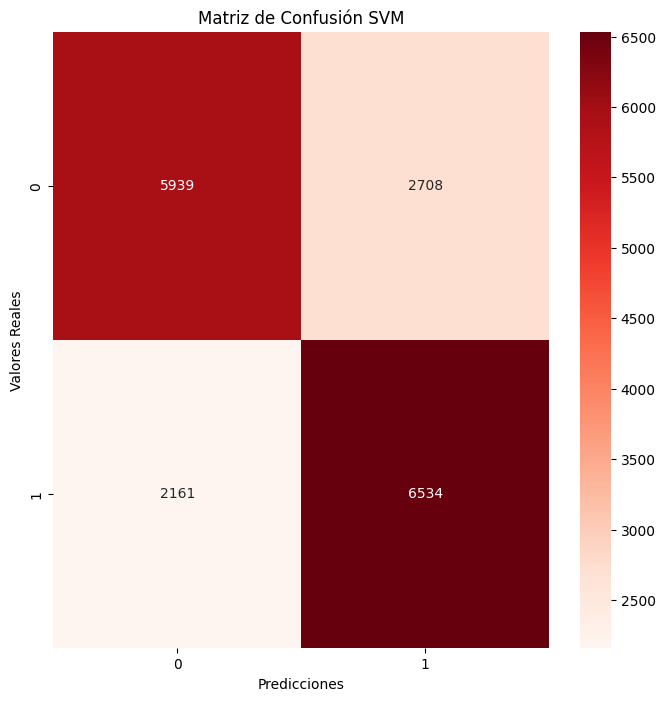

In [ ]:
plt.figure(figsize=(8, 8))
sns.heatmap(cm, xticklabels=["0", "1"], yticklabels=["0", "1"], annot=True, fmt="d", cmap="Reds")
plt.title("Matriz de Confusión SVM")
plt.ylabel('Valores Reales')
plt.xlabel('Predicciones')
plt.show()


- Observaciones: La exactitud total del modelo es del 90%, pero los promedios macro muestran que está fallando en la clase 1, con un promedio de 0.45 para la precisión y 0.50 para el recall. En resumen, aunque el modelo es efectivo para la clase 0, necesita mejoras significativas para poder clasificar correctamente la clase 1.

# Modelo de clasificacion 3 Random Forest (100 cantidad de arboles)

              precision    recall  f1-score   support

           0       0.93      0.89      0.91      8647
           1       0.90      0.93      0.92      8695

    accuracy                           0.91     17342
   macro avg       0.91      0.91      0.91     17342
weighted avg       0.91      0.91      0.91     17342

Precisión: 0.91


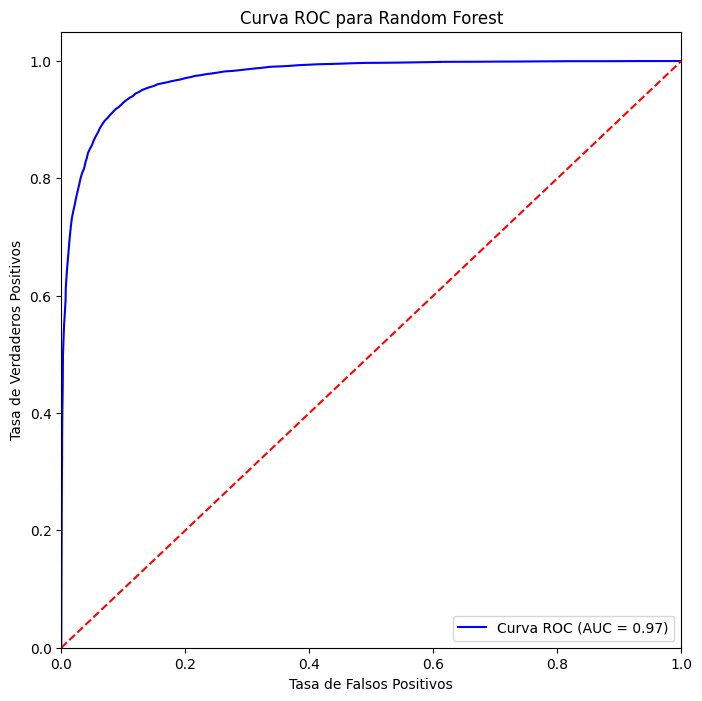

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_curve, auc
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# 1. Preparar los datos
# Separar características y variable objetivo
X = df_escalado.drop(columns=['target'])  # Variables predictoras
y = df_escalado['target']  # Variable objetivo

# 2. Entrenar el modelo de Random Forest
classified = RandomForestClassifier(n_estimators=100, bootstrap=True, max_features="sqrt", random_state=25)  # Número de árboles de decisión
classified.fit(x_train, y_train)  # Entrenamiento del modelo

# 3. Realizar predicciones
y_pred = classified.predict(x_test)

# 4. Evaluar el modelo
# 5.1. Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# 5.2. Reporte de clasificación
report = classification_report(y_test, y_pred)
print(report)

# 5.3. Precisión
accuracy = accuracy_score(y_test, y_pred)
print(f'Precisión: {accuracy:.2f}')

# 5.4. Curva ROC y AUC
# Calcular las probabilidades de la clase positiva
y_scores = classified.predict_proba(x_test)[:, 1]

# Calcular la curva ROC y AUC
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

# Graficar la curva ROC
plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, color='blue', label='Curva ROC (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Línea diagonal
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC para Random Forest')
plt.legend(loc='lower right')
plt.show()



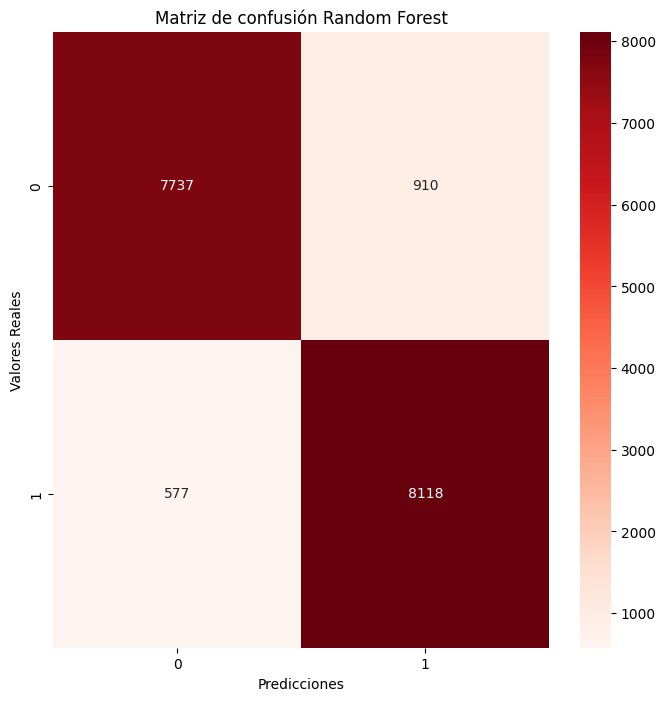

              precision    recall  f1-score   support

           0       0.93      0.89      0.91      8647
           1       0.90      0.93      0.92      8695

    accuracy                           0.91     17342
   macro avg       0.91      0.91      0.91     17342
weighted avg       0.91      0.91      0.91     17342



In [ ]:
plt.figure(figsize=(8, 8))
sns.heatmap(cm, xticklabels=["0","1"], yticklabels=["0","1"], annot=True, fmt="d",cmap="Reds");
plt.title("Matriz de confusión Random Forest")
plt.ylabel('Valores Reales')
plt.xlabel('Predicciones')
plt.show()
print (classification_report(y_test, y_pred))

- Observaciones:El modelo está funcionando muy bien, con una precisión del 93% para la clase 0 y del 90% para la clase 1. El recall es del 89% para la clase 0 y del 93% para la clase 1, lo que indica que identifica correctamente la mayoría de los casos positivos en ambas clases.

# Modelo de clasificacion 4 Random Forest (200 cantidad de arboles)

              precision    recall  f1-score   support

           0       0.93      0.89      0.91      8647
           1       0.90      0.93      0.92      8695

    accuracy                           0.91     17342
   macro avg       0.91      0.91      0.91     17342
weighted avg       0.91      0.91      0.91     17342

Precisión: 91.43%


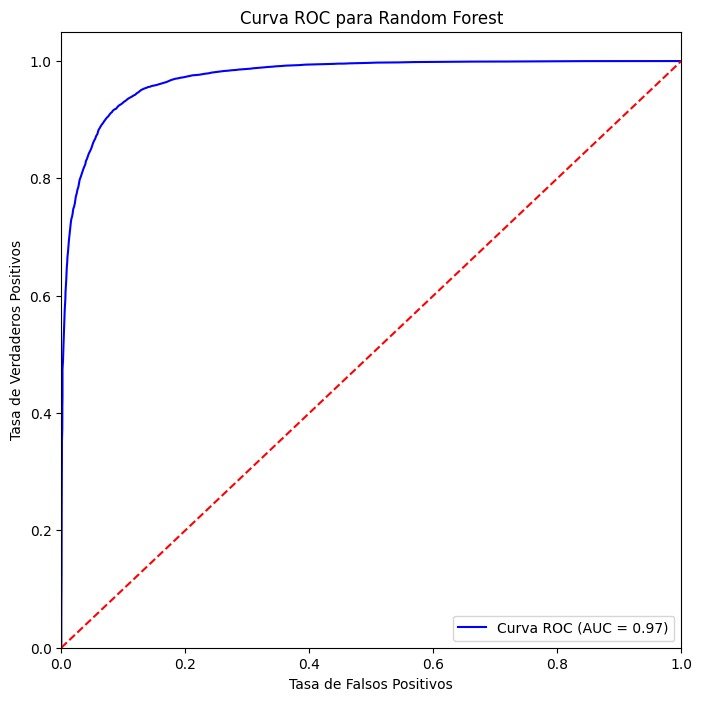

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_curve, auc
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# 1. Preparar los datos
# Separar características y variable objetivo
X = df_escalado.drop(columns=['target'])  # Variables predictoras
y = df_escalado['target']  # Variable objetivo

# 2. Entrenar el modelo de RandomForest
classified = RandomForestClassifier(n_estimators=200, bootstrap=True, max_features="sqrt", random_state=25)  # Número de árboles de decisión
classified.fit(x_train, y_train)  # Entrenamiento del modelo

# 3. Realizar predicciones
y_pred = classified.predict(x_test)

# 4. Evaluar el modelo
# 5.1. Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# 5.2. Reporte de clasificación
report = classification_report(y_test, y_pred)
print(report)

# 5.3. Precisión
accuracy = round(accuracy_score(y_test, y_pred) * 100, 2)
print(f'Precisión: {accuracy}%')

# 5.4. Curva ROC y AUC
# Calcular las probabilidades de la clase positiva
y_scores = classified.predict_proba(x_test)[:, 1]

# Calcular la curva ROC y AUC
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

# Graficar la curva ROC
plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, color='blue', label='Curva ROC (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Línea diagonal
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC para Random Forest')
plt.legend(loc='lower right')
plt.show()


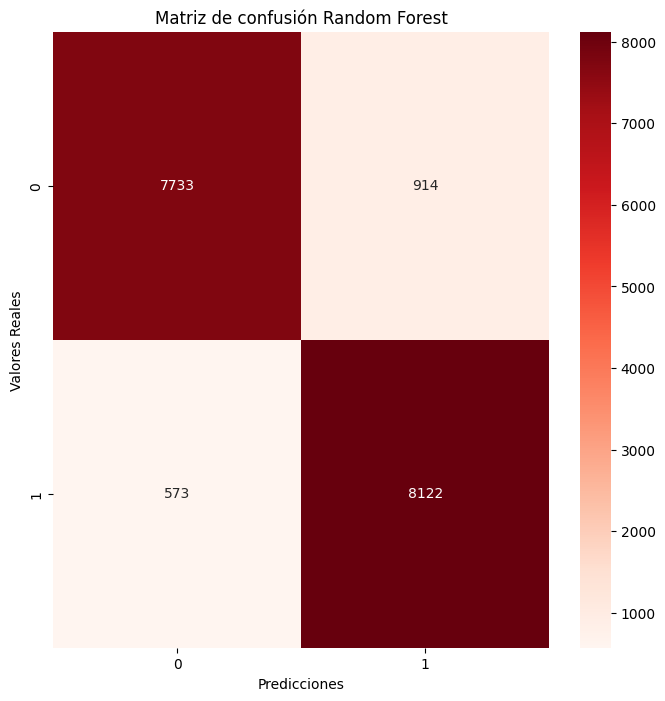

              precision    recall  f1-score   support

           0       0.93      0.89      0.91      8647
           1       0.90      0.93      0.92      8695

    accuracy                           0.91     17342
   macro avg       0.91      0.91      0.91     17342
weighted avg       0.91      0.91      0.91     17342

91.43


In [ ]:
plt.figure(figsize=(8, 8))
sns.heatmap(cm, xticklabels=["0","1"], yticklabels=["0","1"], annot=True, fmt="d",cmap="Reds");
plt.title("Matriz de confusión Random Forest")
plt.ylabel('Valores Reales')
plt.xlabel('Predicciones')
plt.show()
print (classification_report(y_test, y_pred))
print(accuracy)

- Observaciones: El modelo tiene un rendimiento excelente, con una precisión del 93% para la clase 0 y del 90% para la clase 1. El recall es del 89% para la clase 0 y del 93% para la clase 1. El F1-score promedio es del 91%, y la exactitud total es del 91%. En resumen, el modelo está funcionando muy bien.

# Modelo de clasificacion 5 KNN classifier

              precision    recall  f1-score   support

           0       0.93      0.89      0.91      8647
           1       0.90      0.93      0.92      8695

    accuracy                           0.91     17342
   macro avg       0.91      0.91      0.91     17342
weighted avg       0.91      0.91      0.91     17342

Precisión: 91.43%


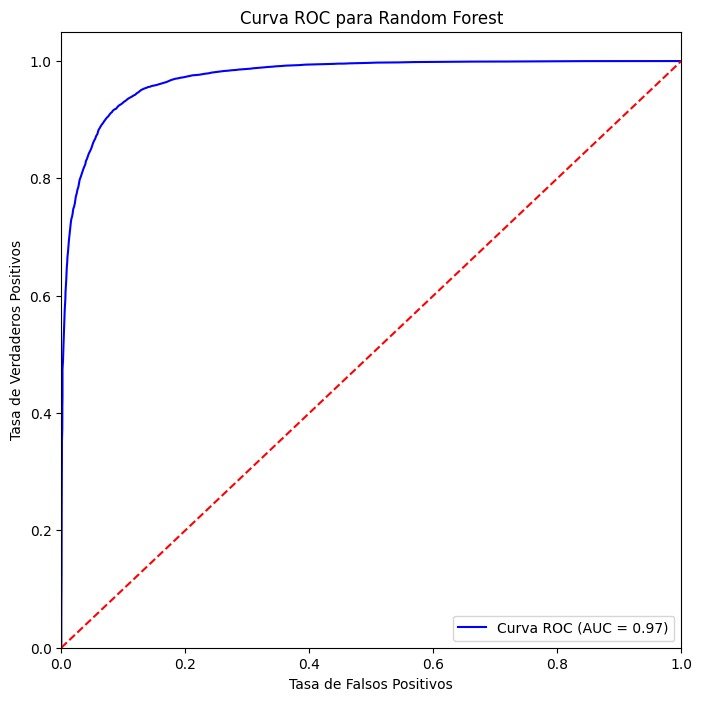

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_curve, auc
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# 1. Preparar los datos
# Separar características y variable objetivo
X = df_escalado.drop(columns=['target'])  # Variables predictoras
y = df_escalado['target']  # Variable objetivo

# 3. Entrenar el modelo de RandomForest
classified = RandomForestClassifier(n_estimators=200, bootstrap=True, max_features="sqrt", random_state=25)  # Número de árboles de decisión
classified.fit(x_train, y_train)  # Entrenamiento del modelo

# 4. Realizar predicciones
y_pred = classified.predict(x_test)

# 5. Evaluar el modelo
# 5.1. Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# 5.2. Reporte de clasificación
report = classification_report(y_test, y_pred)
print(report)

# 5.3. Precisión
accuracy = round(accuracy_score(y_test, y_pred) * 100, 2)
print(f'Precisión: {accuracy}%')

# 5.4. Curva ROC y AUC
# Calcular las probabilidades de la clase positiva
y_scores = classified.predict_proba(x_test)[:, 1]

# Calcular la curva ROC y AUC
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

# Graficar la curva ROC
plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, color='blue', label='Curva ROC (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Línea diagonal
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC para Random Forest')
plt.legend(loc='lower right')
plt.show()

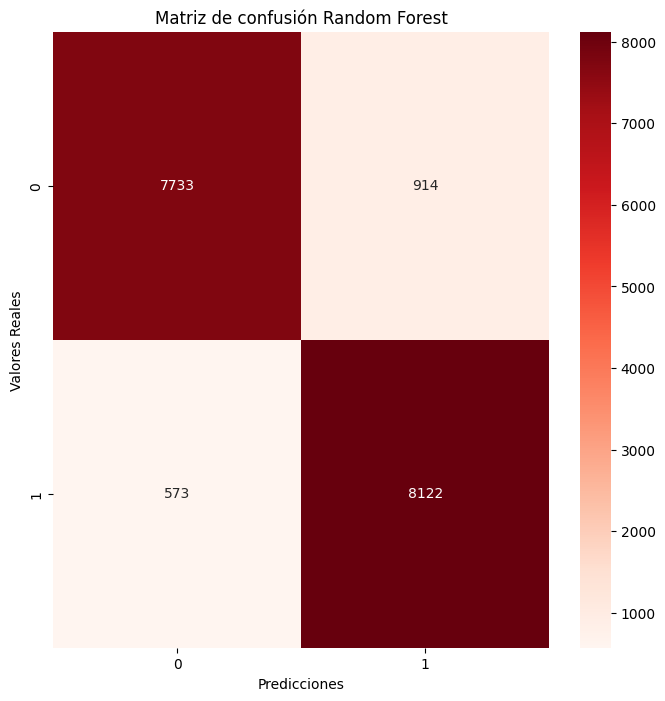

              precision    recall  f1-score   support

           0       0.93      0.89      0.91      8647
           1       0.90      0.93      0.92      8695

    accuracy                           0.91     17342
   macro avg       0.91      0.91      0.91     17342
weighted avg       0.91      0.91      0.91     17342



In [ ]:
plt.figure(figsize=(8, 8))
sns.heatmap(cm, xticklabels=["0","1"], yticklabels=["0","1"], annot=True, fmt="d",cmap="Reds");
plt.title("Matriz de confusión Random Forest")
plt.ylabel('Valores Reales')
plt.xlabel('Predicciones')
plt.show()
print (classification_report(y_test, y_pred))

- Observaciones: El modelo muestra un rendimiento aceptable, con una precisión del 98% para la clase 0 y del 78% para la clase 1. Sin embargo, el recall es bajo para la clase 0 (72%) y alto para la clase 1 (98%), lo que significa que tiene dificultades para identificar los casos de la clase 0. El F1-score promedio es del 85%, y la exactitud total es del 85%. En general, el modelo funciona bien para la clase 1, pero necesita mejorar en la detección de la clase 0.

# Modelo de clasificacion 6 Regresión Logistica

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Precisión: 73.72%
              precision    recall  f1-score   support

           0       0.74      0.74      0.74      8647
           1       0.74      0.74      0.74      8695

    accuracy                           0.74     17342
   macro avg       0.74      0.74      0.74     17342
weighted avg       0.74      0.74      0.74     17342



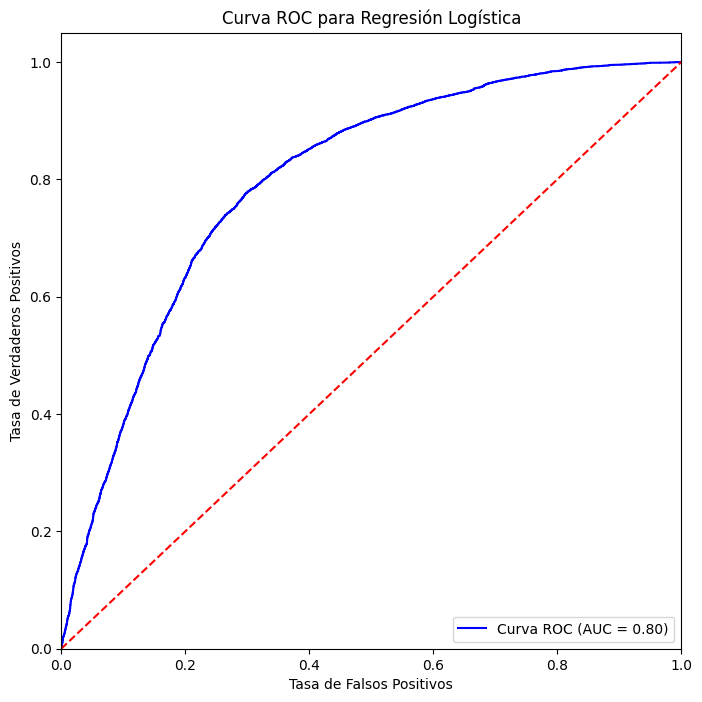

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_curve, auc
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

# 1. Preparar los datos
# Separar características y variable objetivo
X = df_escalado.drop(columns=['target'])  # Variables predictoras
y = df_escalado['target']  # Variable objetivo

# 2. Dividir los datos en conjunto de entrenamiento y prueba

# 3. Entrenar el modelo de Regresión Logística
lr = LogisticRegression(random_state=42, max_iter=500)
lr.fit(x_train, y_train)  # Entrenamiento del modelo

# 4. Realizar predicciones
y_pred = lr.predict(x_test)

# 5. Evaluar el modelo
# 5.1. Precisión
accuracy = round(accuracy_score(y_test, y_pred) * 100, 2)
print(f'Precisión: {accuracy}%')

# 5.3. Reporte de clasificación
report = classification_report(y_test, y_pred)
print(report)

# 5.4. Curva ROC y AUC
# Calcular las probabilidades de la clase positiva
y_scores = lr.predict_proba(x_test)[:, 1]

# Calcular la curva ROC y AUC
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

# Graficar la curva ROC
plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, color='blue', label='Curva ROC (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Línea diagonal
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC para Regresión Logística')
plt.legend(loc='lower right')
plt.show()


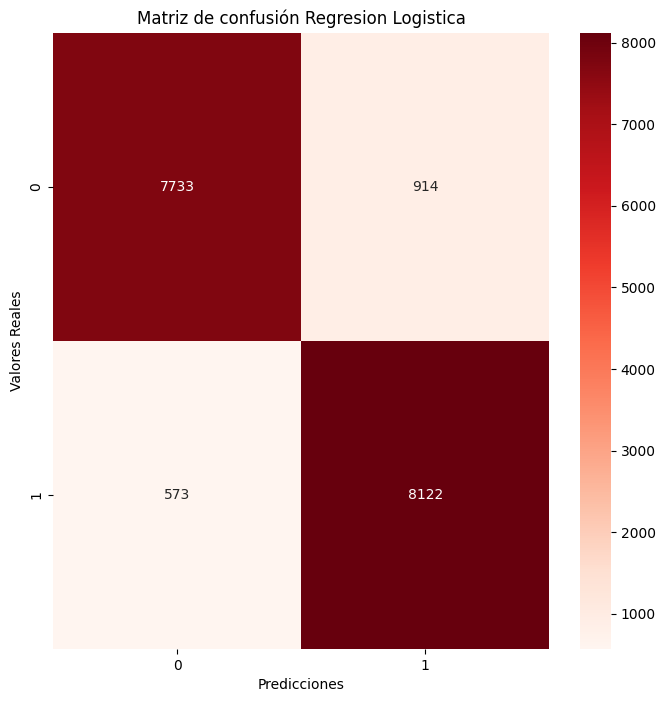

              precision    recall  f1-score   support

           0       0.74      0.74      0.74      8647
           1       0.74      0.74      0.74      8695

    accuracy                           0.74     17342
   macro avg       0.74      0.74      0.74     17342
weighted avg       0.74      0.74      0.74     17342



In [ ]:
plt.figure(figsize=(8, 8))
sns.heatmap(cm, xticklabels=["0","1"], yticklabels=["0","1"], annot=True, fmt="d",cmap="Reds");
plt.title("Matriz de confusión Regresion Logistica")
plt.ylabel('Valores Reales')
plt.xlabel('Predicciones')
plt.show()
print (classification_report(y_test, y_pred))

-Observaciones: El modelo tiene un rendimiento moderado, con una precisión del 74% y un recall similar para ambas clases (0 y 1). La exactitud total es del 74%, y los promedios también son de 0.74. En resumen, el modelo muestra un rendimiento equilibrado, pero necesita mejoras para aumentar su precisión y capacidad de identificación.

### 2.5 Evaluación de los modelos

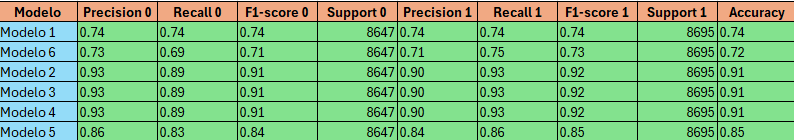

#Conclusiones generales
La evaluación de los modelos de clasificación revela variaciones en su rendimiento:

Modelo 1 y Modelo 6 tienen un rendimiento moderado, con precisiones y recalls alrededor de 0.74 y 0.73, respectivamente. Ambos son adecuados, pero hay espacio para mejoras.

Modelos 2, 3 y 4 muestran un rendimiento superior, con precisiones de 0.93 y recalls de 0.89 para la clase 0, y precisiones de 0.90 y recalls de 0.93 para la clase 1, alcanzando F1-scores superiores a 0.91 y exactitudes de 0.91. Estos son los más recomendados para aplicaciones críticas.

Modelo 5 ofrece un rendimiento bueno, pero inferior a los anteriores, con F1-scores de 0.84 y exactitudes de 0.85.

#Eleccion de modelo
Basado en las métricas de rendimiento, los Modelos 2, 3 y 4 son los mejores. Estos modelos presentan:

Precisión: 0.93 para la clase 0 y 0.90 para la clase 1.
Recall: 0.89 para la clase 0 y 0.93 para la clase 1.
F1-score: superior a 0.91.
Exactitud (Accuracy): 0.91.
Estos resultados indican que estos modelos son los más equilibrados y efectivos para detectar ambas clases, lo que los convierte en las mejores opciones para aplicaciones donde se requiere un alto rendimiento en la clasificación.

## Conclusiones

A lo largo de este trabajo, hemos identificado la importancia de las distintas etapas en la creación de un modelo de datos, así como la relevancia de la correlación en el desarrollo de modelos tanto de regresión como de clasificación. La selección adecuada de los datos y su correcta preparación, incluyendo el manejo de valores nulos, escalamiento y balanceo de clases resultan fundamentales para manejar correctamente los datos que se utilizarán en la elaboración de los modelos.

Los modelos de regresión, incluidos el lineal y el polinómico, mostraron un desempeño inferior, con la mejor precisión alcanzando solo un 0.24. Esto indica que su capacidad para predecir resultados es limitada en comparación con los modelos de clasificación. En contraste, los modelos de clasificación, como los árboles de decisión, Random Forest y KNN, lograron F1-scores superiores a 0.85, mostrando asi una mayor eficacia en la tarea de clasificación.

En conclusión, los modelos de clasificación demostraron ser más precisos y efectivos en general para la tarea que fueron seleccionados, resaltando la necesidad de elegir el enfoque y modelo adecuado adecuado según el problema a resolver.

# <font color='teal'>3. Parte III: Modelos no Supervisados</font>



###3.1 Pregunta a responder


¿Puedo agrupar a mis clientes según las características de los productos financieros que utilizan?

### 3.2 Preparacion de los datos

Variables a utilizar


Renta

Refleja la capacidad económica general del cliente.

Cupo L1

Indica el monto disponible para compras nacionales con tarjeta de crédito.

Fac_T01

Representa el total facturado con tarjeta de crédito, un indicador global del uso de este producto.

FacCCPC_T01

Mide el monto facturado en cuotas precio contado con tarjeta de crédito, mostrando preferencias de pago.

FacDebCom_T01

Representa los montos facturados en compras realizadas con tarjeta de débito, cubriendo el uso principal de este producto.

FacDebAtm_T01

Refleja montos facturados en avances realizados con tarjeta de débito, mostrando otro patrón de uso.

PagoNac_T01

Representa los pagos realizados por deuda nacional, relacionado principalmente con el uso de tarjeta de crédito.

PagoInt_T01

Indica los pagos realizados por deuda internacional, completando la visión sobre la capacidad y el comportamiento de pago en crédito.

In [ ]:
# Lista de variables seleccionadas
variables_seleccionadas = [
    "Renta",
    "CUPO_L1",
    "Fac_T01",
    "FacCCPC_T01",
    "FacDebCom_T01",
    "FacDebAtm_T01",
    "PagoNac_T01",
    "PagoInt_T01"
]

# Crear un nuevo DataFrame con las variables seleccionadas
df_sn = df[variables_seleccionadas]


Se convierte los datos a numeric para poder manejarlos

In [ ]:
import pandas as pd

# Suponiendo que df_filtrado ya está definido
# Convertir todas las columnas a tipo numérico, forzando errores a NaN
df_sn = df_sn.apply(pd.to_numeric, errors='coerce')

# Ver los primeros registros del DataFrame convertido
print(df_sn.head())

# Verificar si hay valores NaN después de la conversión
print("\nValores NaN por columna:")
print(df_sn.isna().sum())


      Renta  CUPO_L1  Fac_T01  FacCCPC_T01  FacDebCom_T01  FacDebAtm_T01  \
0       NaN   798000        0            0         204133          24000   
1  143640.0   750000   118247       118247              0              0   
2  929106.0  1350000   191336            0         162161         519000   
3  172447.0  1570800    11890        11890              0              0   
4  805250.0  2762000   173576        70808              0              0   

   PagoNac_T01  PagoInt_T01  
0        33000          0.0  
1       300000          0.0  
2       216676          0.0  
3        60000          0.0  
4       272925          0.0  

Valores NaN por columna:
Renta            13371
CUPO_L1              0
Fac_T01              0
FacCCPC_T01          0
FacDebCom_T01        0
FacDebAtm_T01        0
PagoNac_T01          0
PagoInt_T01        300
dtype: int64


Transformacion de datos que sean tipo object

In [ ]:
object_columns_before = df_sn.select_dtypes(include=['object']).columns.tolist()
print("Columnas con tipo de dato 'object' antes de la imputación:")
print(object_columns_before)


Columnas con tipo de dato 'object' antes de la imputación:
[]


In [ ]:
for col in object_columns_before:
    df_sn.loc[:, col] = df_sn[col].astype(str).str.replace(',', '.', regex=False)
    df_sn[col] = df_sn[col].astype(float)

In [ ]:
object_columns_after = df_sn.select_dtypes(include=['object']).columns.tolist()
print("Columnas con tipo de dato 'object' despúes de la imputación:")
print(object_columns_after)

Columnas con tipo de dato 'object' despúes de la imputación:
[]


Aplicamos KNN para los nulos en renta

In [ ]:
import pandas as pd
from sklearn.impute import KNNImputer

# 1. Crear una copia del DataFrame original para preservar df_sn
df_sn_imputado = df_sn.copy()

# 2. Separar la columna Renta y las variables predictoras
X_sn = df_sn_imputado.drop(columns=['Renta'])  # Variables predictoras
y_sn = df_sn_imputado[['Renta']]  # Columna objetivo (Renta) con valores nulos

# 3. Unir ambas partes para preparar el imputador
data_sn_para_imputar = pd.concat([X_sn, y_sn], axis=1)

# 4. Inicializar el KNNImputer (k=5 vecinos)
imputer_sn = KNNImputer(n_neighbors=5)

# 5. Imputar los valores nulos solo en la columna Renta
data_sn_imputada = pd.DataFrame(imputer_sn.fit_transform(data_sn_para_imputar),
                                columns=data_sn_para_imputar.columns)

# 6. Actualizar la columna Renta con los valores imputados
df_sn_imputado['Renta'] = data_sn_imputada['Renta']

# 7. Verificar si quedan nulos en la columna Renta
print('Número de datos nulos en renta después de la imputación:')
print(df_sn_imputado['Renta'].isnull().sum())



Número de datos nulos en renta después de la imputación:
0


In [ ]:
for i in df_sn_imputado.columns:
  print('Porcentaje de nulos en el dataframe', i, '=',round(((df_sn_imputado[i].isna().sum())*100)/51124,2),'%')

Porcentaje de nulos en el dataframe Renta = 0.0 %
Porcentaje de nulos en el dataframe CUPO_L1 = 0.0 %
Porcentaje de nulos en el dataframe Fac_T01 = 0.0 %
Porcentaje de nulos en el dataframe FacCCPC_T01 = 0.0 %
Porcentaje de nulos en el dataframe FacDebCom_T01 = 0.0 %
Porcentaje de nulos en el dataframe FacDebAtm_T01 = 0.0 %
Porcentaje de nulos en el dataframe PagoNac_T01 = 0.0 %
Porcentaje de nulos en el dataframe PagoInt_T01 = 0.59 %


In [ ]:
df_sn_imputado = df_sn_imputado.dropna(subset=["PagoInt_T01"])

3.2.4 Escalamiento de los datos

In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np


# 1. Crear el escalador
scaler = StandardScaler()

# 2. Identificar las columnas numéricas en df_sn_imputado
numerical_cols = df_sn_imputado.select_dtypes(include=[np.number]).columns

# 3. Aplicar el escalador y asignar a un nuevo DataFrame escalado
df_sn_imputado_scaled = df_sn_imputado.copy()
df_sn_imputado_scaled[numerical_cols] = scaler.fit_transform(df_sn_imputado[numerical_cols])

# Ver los datos escalados
print("Datos escalados (primeras filas):")
print(df_sn_imputado_scaled.head())





Datos escalados (primeras filas):
      Renta   CUPO_L1   Fac_T01  FacCCPC_T01  FacDebCom_T01  FacDebAtm_T01  \
0 -0.304720 -0.309554 -0.529939    -0.299769       0.865503      -0.566613   
1 -1.307824 -0.354228  0.363181     1.373190      -0.446957      -0.632535   
2  0.789057  0.204195  0.915223    -0.299769       0.595647       0.793037   
3 -1.230921  0.409694 -0.440134    -0.131550      -0.446957      -0.632535   
4  0.458411  1.518349  0.781082     0.702023      -0.446957      -0.632535   

   PagoNac_T01  PagoInt_T01  
0    -0.290541    -0.016105  
1     1.499653    -0.016105  
2     0.940978    -0.016105  
3    -0.109510    -0.016105  
4     1.318119    -0.016105  


3.2.5 Revision de imputar y escalar

In [ ]:
from sklearn.impute import SimpleImputer
import pandas as pd

# Crear un imputador para reemplazar NaN con la media de cada columna
imputer = SimpleImputer(strategy='mean')

# Aplicar el imputador al DataFrame escalado
df_sn_imputado_scaled = pd.DataFrame(imputer.fit_transform(df_sn_imputado_scaled), columns=df_sn_imputado_scaled.columns)

# Verificar si hay valores faltantes
print("Valores faltantes restantes por columna después de imputar y escalar:")
print(df_sn_imputado_scaled.isnull().sum())


Valores faltantes restantes por columna después de imputar y escalar:
Renta            0
CUPO_L1          0
Fac_T01          0
FacCCPC_T01      0
FacDebCom_T01    0
FacDebAtm_T01    0
PagoNac_T01      0
PagoInt_T01      0
dtype: int64


 ### 3.3 Modelos NS





Instalamos kneed para poder usar KneeLocator

In [ ]:
!pip install kneed

In [ ]:
from kneed import KneeLocator


A continuación, desarrollaremos los tres modelos de aprendizaje no supervisado:

K-means: Este algoritmo agrupa los datos asignándolos al cluster con el centroide más cercano, basándose en la minimización de la suma de las distancias cuadradas dentro de cada cluster. Es eficiente y fácil de implementar, aunque sensible a valores atípicos y ruido en los datos.

Cluster Jerárquico: Este método organiza los datos en una estructura jerárquica, creando un árbol de clusters conocido como dendrograma. Permite analizar relaciones entre los datos en diferentes niveles de granularidad y es útil para identificar patrones jerárquicos.

DBScan: Este algoritmo identifica clusters basados en la densidad de puntos. Es especialmente útil para detectar agrupamientos con formas arbitrarias y para manejar datos con ruido, sin requerir la especificación previa del número de clusters.

In [ ]:
# Rango de valores para k
k_values = range(1, 20)

# Lista para almacenar las inercias
inercias = []

for k in k_values:
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(X_pca)
    inercias.append(kmeans.inertia_)

In [ ]:
#Obtenemos donde se encuentra el codo sin necesidad de graficar
kNumber = range(1, 20)
sse = []
kl = KneeLocator(kNumber, inercias, curve="convex", direction="decreasing")

print("El codo está en k =", kl.elbow)

El codo está en k = 5


Este resultado anteriormente era 7

Varianza explicada por los dos primeros componentes: 0.41562299779158607


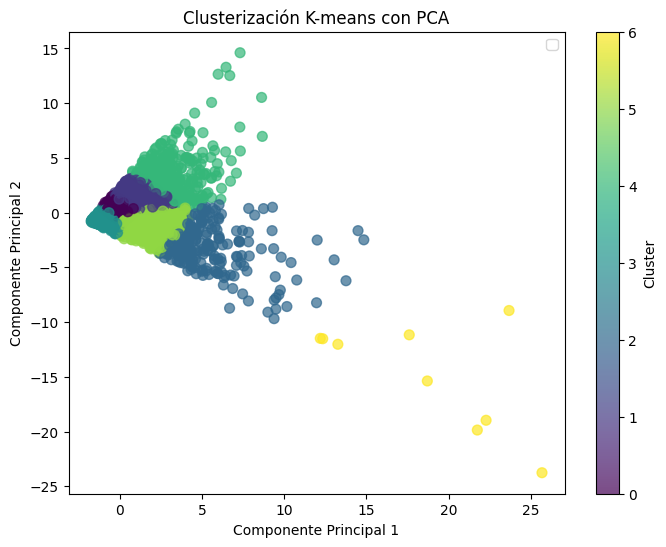

Silhouette Score: 0.38734896136034846
Coeficiente Calinski-Harabasz: 9335.31349570715


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from kneed import KneeLocator
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score

# Escalar los datos si aún no se han escalado
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_sn_imputado_scaled)

# Convertir el arreglo escalado a un DataFrame para tomar una muestra
df_scaled_df = pd.DataFrame(df_scaled, columns=[f"Feature_{i+1}" for i in range(df_scaled.shape[1])])

# Tomar el 30% de los datos de forma aleatoria
df_sample = df_scaled_df.sample(frac=0.3, random_state=10)

df_sample_np = df_sample.to_numpy()

# 1. Aplicar PCA para reducir la dimensionalidad a 2 componentes principales
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_sample_np)

# Verificar la varianza explicada por los dos primeros componentes
print(f"Varianza explicada por los dos primeros componentes: {sum(pca.explained_variance_ratio_)}")

# 3. Aplicar KMeans con el número óptimo de clusters
kmeans = KMeans(n_clusters=7, random_state=10)
kmeans.fit(X_pca)

# Obtener las etiquetas (clusters asignados)
labels = kmeans.labels_

# 4. Visualizar los resultados de KMeans en el espacio reducido (PCA)
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', s=50, alpha=0.7, marker='o')  # Puntos
plt.title("Clusterización K-means con PCA")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.colorbar(label='Cluster')
plt.legend()
plt.show()

# 5. Calcular métricas de evaluación del modelo
silhouette = silhouette_score(X_pca, labels)
ch_score = calinski_harabasz_score(X_pca, labels)

print(f"Silhouette Score: {silhouette}")
print(f"Coeficiente Calinski-Harabasz: {ch_score}")

In [ ]:
# 6. Contar el número de puntos por clúster
cluster_counts = np.bincount(labels)
for i, count in enumerate(cluster_counts):
    print(f"Clúster {i+1}: {count} personas")

Clúster 1: 4622 personas
Clúster 2: 1868 personas
Clúster 3: 228 personas
Clúster 4: 6329 personas
Clúster 5: 415 personas
Clúster 6: 1776 personas
Clúster 7: 9 personas


3.3.2  Algoritmo DBS Scan

Varianza explicada por los dos primeros componentes: 0.41562299779158607


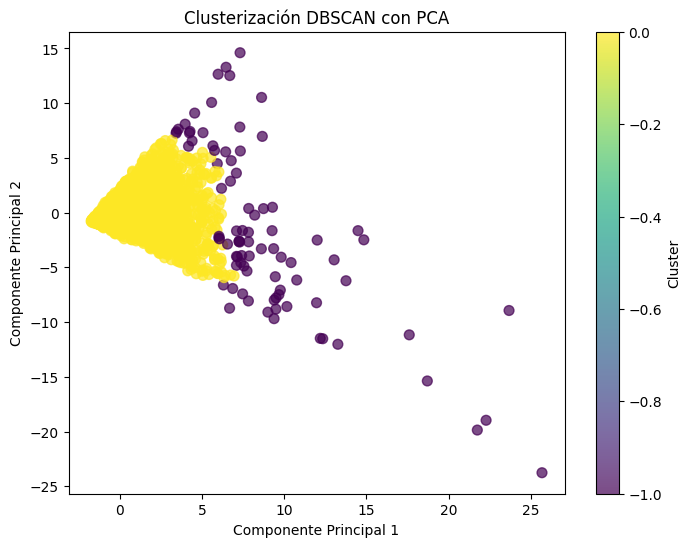

Silhouette Score: 0.8406875438404999
Coeficiente Calinski-Harabasz: 2451.141026629337


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Escalar los datos si aún no se han escalado
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_sn_imputado_scaled)

# Convertir el arreglo escalado a un DataFrame para tomar una muestra
df_scaled_df = pd.DataFrame(df_scaled, columns=[f"Feature_{i+1}" for i in range(df_scaled.shape[1])])

# Tomar el 30% de los datos de forma aleatoria
df_sample = df_scaled_df.sample(frac=0.3, random_state=10)

# Convertir la muestra nuevamente a NumPy
df_sample_np = df_sample.to_numpy()

# 1. Aplicar PCA para reducir la dimensionalidad a 2 componentes principales
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_sample_np)

# Verificar la varianza explicada por los dos primeros componentes
print(f"Varianza explicada por los dos primeros componentes: {sum(pca.explained_variance_ratio_)}")

# 2. Aplicar DBSCAN sobre los datos reducidos (PCA)
dbscan = DBSCAN(eps=0.6, min_samples=5)

# Aplicar DBSCAN y obtener las etiquetas de los clusters
labels = dbscan.fit_predict(X_pca)

# 3. Visualizar los resultados de DBSCAN en el espacio reducido
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', s=50, alpha=0.7, marker='o')  # Puntos
plt.title("Clusterización DBSCAN con PCA")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.colorbar(label='Cluster')
plt.show()

# 4. Calcular el Silhouette Score
silhouette = silhouette_score(X_pca, labels)
ch_score = calinski_harabasz_score(X_pca, labels)

print(f"Silhouette Score: {silhouette}")
print(f"Coeficiente Calinski-Harabasz: {ch_score}")



3.3.3 Algoritmo a Cluster jerarquico Aglomerative



Varianza explicada por los dos primeros componentes: 0.41562299779158607


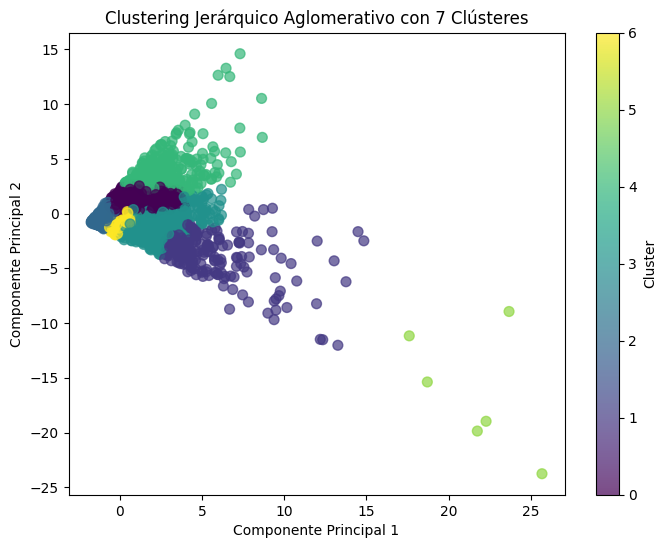

Silhouette Score: 0.33786282212023944
Coeficiente Calinski-Harabasz: 7829.8074215490415


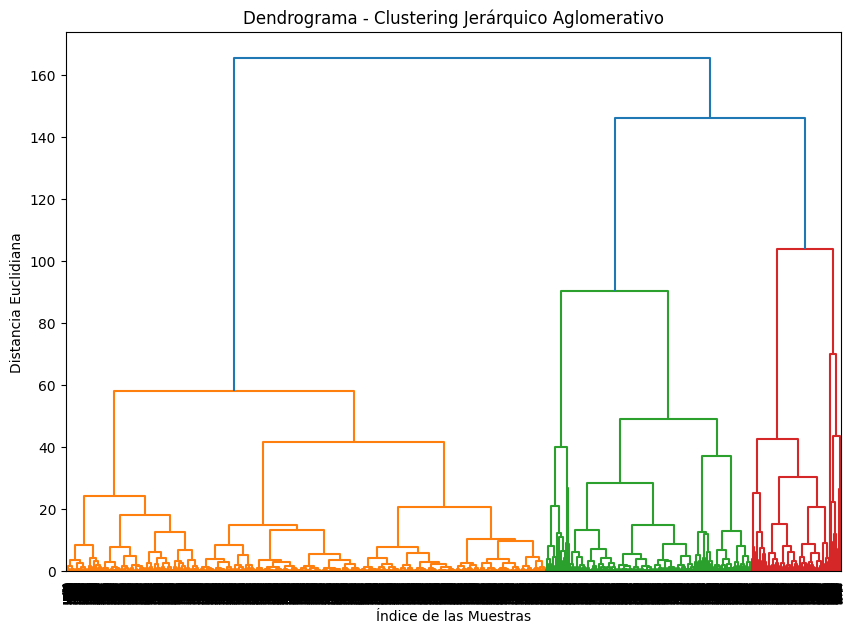

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage

# Escalar los datos si aún no se han escalado
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_sn_imputado_scaled)

# Convertir el arreglo escalado a un DataFrame para tomar una muestra
df_scaled_df = pd.DataFrame(df_scaled, columns=[f"Feature_{i+1}" for i in range(df_scaled.shape[1])])

# Tomar el 30% de los datos de forma aleatoria
df_sample = df_scaled_df.sample(frac=0.3, random_state=10)

# Convertir la muestra nuevamente a NumPy
df_sample_np = df_sample.to_numpy()

# 1. Aplicar PCA para reducir la dimensionalidad a 2 componentes principales
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_sample_np)

# Verificar la varianza explicada por los dos primeros componentes
print(f"Varianza explicada por los dos primeros componentes: {sum(pca.explained_variance_ratio_)}")

# 2. Aplicar Agglomerative Clustering sobre los datos reducidos (PCA)
# Determina el número de clusters, por ejemplo, de manera manual o utilizando el codo (en este caso se elige un valor de 7 como ejemplo)
kl_elbow = 7  # Puedes determinar este valor usando el análisis del codo

agg_clustering = AgglomerativeClustering(n_clusters=kl_elbow, linkage='ward')
labels = agg_clustering.fit_predict(X_pca)

# 3. Visualizar los resultados del clustering en el espacio reducido
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', s=50, alpha=0.7, marker='o')  # Puntos
plt.title(f"Clustering Jerárquico Aglomerativo con {kl_elbow} Clústeres")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.colorbar(label='Cluster')
plt.show()

silhouette = silhouette_score(X_pca, labels)
ch_score = calinski_harabasz_score(X_pca, labels)

print(f"Silhouette Score: {silhouette}")
print(f"Coeficiente Calinski-Harabasz: {ch_score}")



# 5. Visualizar el dendrograma
Z = linkage(X_pca, method='ward')
plt.figure(figsize=(10, 7))
dendrogram(Z)
plt.title("Dendrograma - Clustering Jerárquico Aglomerativo")
plt.xlabel("Índice de las Muestras")
plt.ylabel("Distancia Euclidiana")
plt.show()


 ### 3.4 Eleccion del modelo

3.4.1 Metricas a utilizar



Silhouette:

Esta métrica mide qué tan bien se agrupan los datos dentro de sus clusters. Un valor cercano a 1 indica buenos grupos, mientras que valores cercanos a -1 indican que los puntos están mal agrupados.

Calinski-Harabasz:

Esta métrica evalúa la dispersión de los clusters y la separación entre ellos. Un valor más alto indica un mejor rendimiento del modelo en términos de formar clusters bien separados.

3.4.2 Comparacion de los modelos

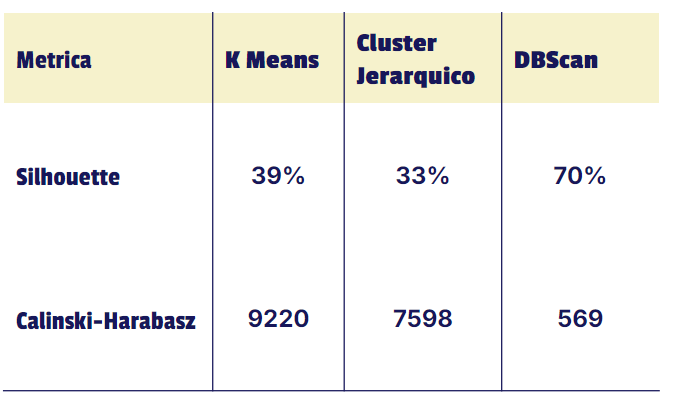

Métrica Silhouette:

K-means: 39%
K-means tiene un valor de 39%, lo que indica una cohesión moderada dentro de los clusters, pero los puntos dentro de los mismos no están tan bien agrupados. Es un desempeño intermedio donde hay algo de separación entre los clusters, pero los puntos no están tan bien ajustados a sus respectivos grupos. Esto puede suceder cuando el número de clusters no es óptimo o cuando la distribución de los datos no es bien representada por formas esféricas


Cluster Jerárquico: 33%
El Cluster Jerárquico tiene un valor de 33%, lo que indica que los clusters generados son menos cohesivos que los de K-means. Aunque el modelo intenta dividir los datos en grupos jerárquicos, la calidad del agrupamiento es más baja, lo que sugiere que los clusters no están bien definidos. Este valor bajo en Silhouette refleja que los puntos dentro de los clusters no están lo suficientemente cerca unos de otros, y la separación entre clusters tampoco es lo suficientemente clara.

DBScan: 70%
DBScan tiene un excelente valor de 70% en la métrica Silhouette. Este valor alto indica que los puntos dentro de cada cluster están muy cercanos unos a otros, lo que sugiere que DBScan está produciendo clusters muy bien definidos y cohesionados. Esta es la mejor puntuación de los tres modelos, lo que muestra que DBScan es el que mejor agrupa los datos en términos de cohesión interna, sin importar la separación entre los clusters. Este desempeño es particularmente bueno en situaciones donde los datos no siguen una distribución esférica o tienen una forma más irregular.

2. Métrica Calinski-Harabasz:

K-means: 9220
K-means tiene el valor más alto de 9220 en la métrica Calinski-Harabasz, lo que indica que este modelo es excelente en la separación entre los clusters. Esto significa que, en términos de distancia, los clusters generados por K-means son bien separados, lo que es ideal si el objetivo es que los grupos estén lo más distantes posible entre sí. Sin embargo, este valor alto no necesariamente implica que los puntos dentro de cada cluster estén bien agrupados , ya que no refleja la cohesión interna de los clusters.

Cluster Jerárquico: 7598
El valor de 7598 para el Cluster Jerárquico es bueno, pero no tan alto como el de K-means. Esto sugiere que, aunque los clusters generados por el modelo jerárquico están relativamente separados entre sí, la separación no es tan pronunciada como en K-means. Este valor indica que el modelo jerárquico tiene una buena dispersión entre los clusters, pero podría mejorar en cuanto a la distancia relativa entre ellos si se comparara con K-means.

DBScan: 569
DBScan tiene un valor bajo de 569 en la métrica Calinski-Harabasz, lo que sugiere que los clusters generados no están tan bien separados en comparación con K-means y el Cluster Jerárquico. Esto es un reflejo de cómo DBScan agrupa los puntos: puede crear clusters de formas irregulares y, a menudo, permite que puntos que no se ajustan a un modelo tradicional de clusters queden excluidos o se agrupen en un cluster separado. Este valor bajo refleja que, aunque los clusters de DBScan son cohesionados, no son tan distintos entre sí.

3.4.2 Eleccion del modelo

Basado en el análisis de las métricas de desempeño de los tres modelos de clustering evaluados (K-means, Cluster Jerárquico y DBScan), podemos concluir que DBScan es la opción más adecuada para este caso.

DBScan destaca por su sobresaliente desempeño en la métrica Silhouette (70%), lo que indica que genera agrupamientos más cohesivos y mejor definidos en comparación con los otros dos modelos. Aunque K-means tiene una buena separación según la métrica Calinski-Harabasz (9220), su menor puntuación en Silhouette (39%) sugiere que los clusters son menos cohesivos, lo que puede ser un inconveniente dependiendo de la naturaleza de los datos. Por otro lado, el Cluster Jerárquico presenta un desempeño inferior en ambas métricas, lo que hace que no sea la mejor opción en este caso.

En resumen, DBScan es el modelo más adecuado si el objetivo principal es obtener agrupamientos bien definidos y de alta calidad, superando a K-means y al Cluster Jerárquico en términos de cohesión de los clusters.

 ### 3.5 Conclusiones

En este trabajo aprendimos sobre distintos algoritmos de clustering para modelos, como K-means, Cluster Jerárquico y DBScan, lo que nos permitió comprender sus características y seleccionar el más adecuado según los datos. K-means agrupa los datos asignándolos al cluster con el centroide más cercano, siendo eficiente pero sensible a datos ruidosos. Cluster Jerárquico organiza los datos en una estructura jerárquica, facilitando el análisis de relaciones en diferentes niveles de granularidad. Por otro lado, DBScan identifica clusters en función de la densidad, siendo especialmente útil para datos con formas complejas y presencia de ruido.

También exploramos el uso del método del codo para determinar el número óptimo de clusters, lo que ayudó a optimizar los modelos al identificar el punto donde la mejora en la calidad de los agrupamientos se vuelve marginal. Además, evaluamos los resultados con métricas clave como Silhouette, que mide la cohesión y separación entre clusters, y Calinski-Harabasz, que analiza la dispersión relativa entre ellos. Este enfoque nos permitió interpretar los resultados de manera crítica, equilibrando cohesión y separación para seleccionar el modelo más adecuado.

En general, este trabajo nos permitió fortalecer nuestras habilidades en machine learning no supervisado, aplicando técnicas y métricas esenciales para el análisis de datos, la evaluación de su desempeño mediante índices como el coeficiente de Silhouette y la inercia. Además, entendimos claramente la diferencia entre el aprendizaje supervisado, que se basa en datos etiquetados para predecir salidas específicas, y el no supervisado, que trabaja con datos no etiquetados para encontrar patrones ocultos o tendencias. Esta comprensión nos ayudó a identificar escenarios en los que cada enfoque es más adecuado y a aplicar métodos no supervisados para descubrir información valiosa en datos sin estructura previa, mejorando la calidad de los agrupamientos y la interpretación de resultados.


Para finalizar, la pregunta inicial sí logró ser respondida, ya que se pudieron agrupar los clientes en distintos clústeres, según los productos financieros que estos utilizan, lo cual se refleja en las métricas vistas y los modelos realizados. Adicionalmente, se podrían asignar etiquetas para un análisis más detallado de los nuevos clústeres generados.